# Customer Churn Analysis

## Business problem

Customer churn is a major problem for subscription business. 
Losing customers increases aquisition costs and reduces revenue.

This project analyzes customer data behavior to identify factors associated with churn
and build predictive model to identify customer at risks of leaving.

## Objective

1. Understand customer churn patterns through exploratory data analysis.
2. Identify key factors that influence customer churn.
3. Build an interpretable churn prediction model.
4. Translate model findings into actionable retention strategies.

## Dataset

Dataset:

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Target variable:

`churn`

Goal:

Predict whether a customer is likely to leave to the service.


# 1. Import Libraries

We import the main Python Libraries needed for:

- Data manipulation
- Data visualization
- Machine learning preparation


In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


# 2. Load Dataset

The first step is to load the customer churn dataset and understand its structure.

We will check:

- Number of rows and colunms
- Colunm names
- Data types
- Missing values
- Basic statistics

In [173]:
import os

data_path = "../data/raw/Telco-Customer-Churn.csv"

df = pd.read_csv(data_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [174]:
df.shape

(7043, 21)

# 3. Dataset Overview

Before analysis, we need to understand:

- Colunm data types
- Missing values
- Potential data quality issues

In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [176]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

(df == " ").sum()

# 4. Data Cleaning

The data contains 11 blank values in `TotalCharges`.

These values are converted to missing values and removed because they represent a very portion of the dataset.

In [177]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [178]:
df = df.dropna()

df.shape

(7032, 21)

In [179]:
df.duplicated().sum()

np.int64(0)

# 5. Target Variable Analysis

Understanding the distribution of churn is important because it determines:

- How balanced the dataset is
- Which evaluation metrics we should prioritize
- How common customer churn is

In [180]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

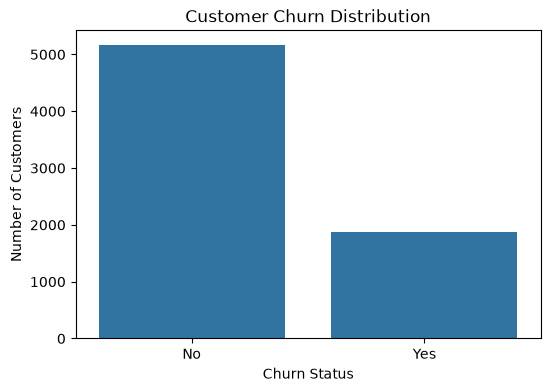

In [181]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [182]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand customer behavior and identify
patterns associated with churn.

We will analyze churn across:

- Customer demographics
- Service usage
- Contract information
- Payment behavior
- Charges

## 1. Does contract type affect churn?

In [183]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


## Insight: Contract Type is Strongly Associated With Churn

Customers with month-to-month contracts have the highest churn rate at 42.7%.

Customers with longer commitments show significantly lower churn:
- One-year contracts: 11.3% churn
- Two-year contracts: 2.8% churn

This suggests that contract commitment is an important factor in customer retention.
The business may reduce churn by encouraging high-risk customers to move from
month-to-month plans to longer-term contracts through targeted incentives.

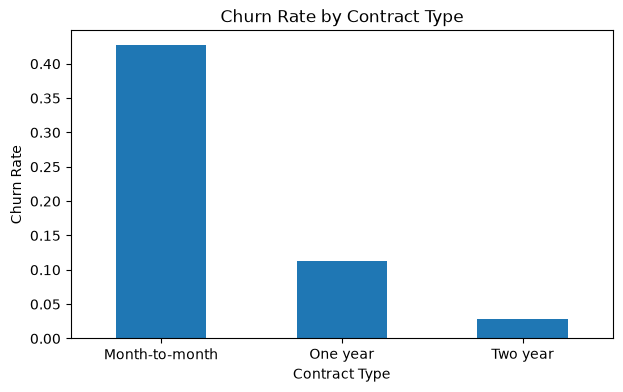

In [184]:
contract_churn["Yes"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)

plt.show()

## Insight: Contract Type and Churn

Contract type is strongly associated with customer churn.

Month-to-month customers have the highest churn rate (42.7%), compared with customers on one-year contracts (11.3%) and two-year contracts (2.8%).

This indicates that customers with flexible contracts represent a higher-risk segment. The business could reduce churn by targeting month-to-month customers with retention offers, loyalty benefits, or incentives to move to longer-term contracts.

## 2. Do newer customers leave more often than long-term customers?

In [185]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

## Customer Tenure Segmentation

To better understand churn behavior, we group customers into tenure ranges.

This helps identify whether new customers or long-term customers are more likely to churn.

In [186]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

df["tenure_group"].value_counts()

tenure_group
49-72 months    2239
0-12 months     2175
25-48 months    1594
13-24 months    1024
Name: count, dtype: int64

In [187]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
)

tenure_churn

Churn,No,Yes
tenure_group,,
0-12 months,0.523218,0.476782
13-24 months,0.712891,0.287109
25-48 months,0.796110,0.203890
49-72 months,0.904868,0.095132


## Insight: Customer Tenure and Churn

Customer tenure is strongly associated with churn risk.

Customers in their first 12 months have the highest churn rate at 47.7%, while long-term customers with 49–72 months of tenure have a much lower churn rate of 9.5%.

This indicates that early customer experience is a critical retention period. The business should focus onboarding improvements, proactive support, and early engagement campaigns on new customers.

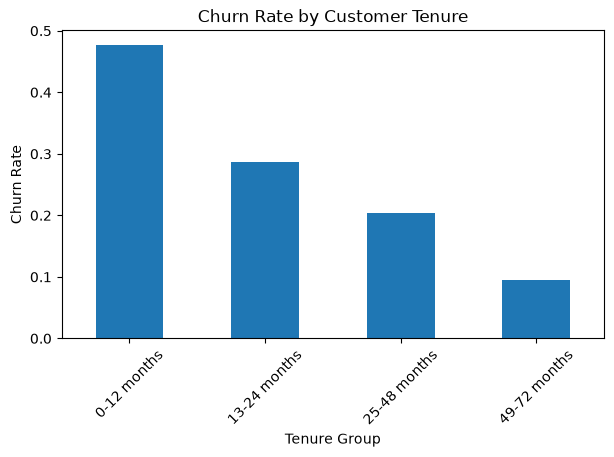

In [188]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group")
plt.xticks(rotation=45)

plt.show()

## Insight: Customer Tenure and Churn

Customer tenure is strongly associated with churn risk.

Customers in their first 12 months have the highest churn rate at 47.7%, while long-term customers with 49–72 months of tenure have a much lower churn rate of 9.5%.

This indicates that early customer experience is a critical retention period. The business should focus onboarding improvements, proactive support, and early engagement campaigns on new customers.

## 3. Does Payment Method Affect Churn?

Payment method may reveal differences in customer behavior and retention risk.

We compare churn rates across payment methods.

In [189]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


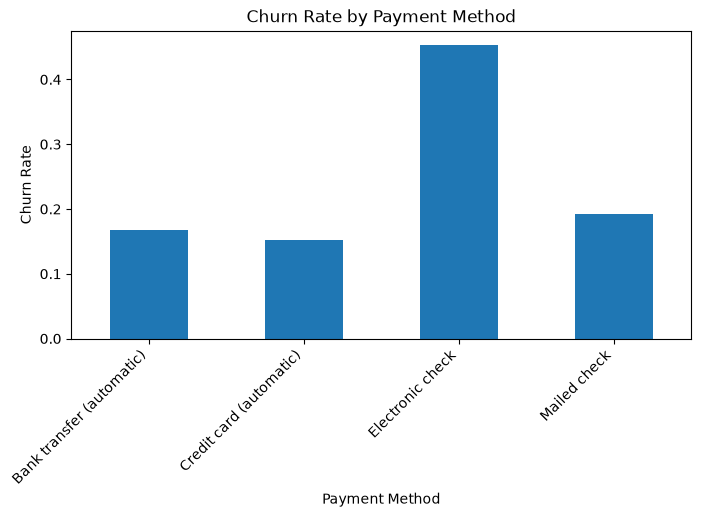

In [190]:
payment_churn["Yes"].plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xlabel("Payment Method")
plt.xticks(rotation=45, ha="right")

plt.show()

## Insight: Payment Method and Churn

Payment method is associated with significant differences in churn behavior.

Customers using electronic checks have the highest churn rate at 45.3%, compared with customers using automatic bank transfer (16.7%) and automatic credit card payments (15.3%).

This suggests that electronic check customers represent a higher-risk segment. The business could investigate billing friction and encourage customers to adopt automatic payment methods through incentives or improved payment experiences.

## 4. Do Monthly Charges Affect Churn?

Monthly charges represent the customer's recurring cost.

We compare monthly charge distributions between customers who stayed and customers who churned.

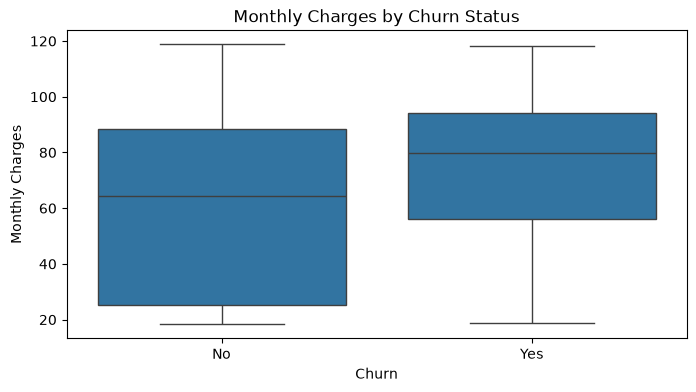

In [191]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [192]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

## Insight: Monthly Charges and Churn

Monthly charges are associated with customer churn.

Customers who churn have a higher average monthly charge ($74.44) compared with customers who stay ($61.31).

This suggests that higher-paying customers may have increased price sensitivity or higher expectations from the service. The business should investigate whether premium customers are receiving enough value and consider targeted retention offers for high-value customers.

## 5. Does Tech Support Affect Churn?

Customer support availability may influence retention.

We compare churn rates between customers with and without technical support.

In [193]:
tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)

tech_support_churn

Churn,No,Yes
TechSupport,,
No,0.583525,0.416475
No internet service,0.925658,0.074342
Yes,0.848039,0.151961


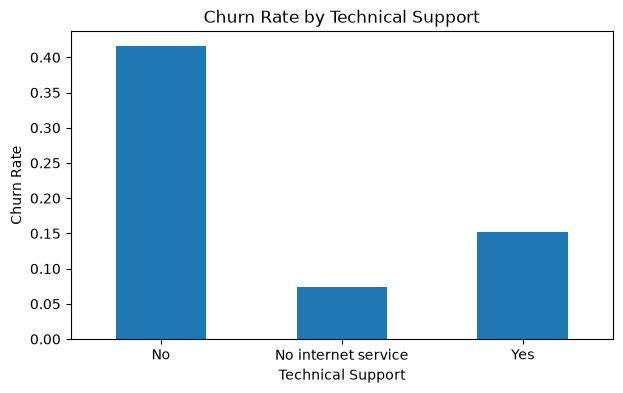

In [194]:
tech_support_churn["Yes"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Churn Rate by Technical Support")
plt.ylabel("Churn Rate")
plt.xlabel("Technical Support")
plt.xticks(rotation=0)

plt.show()

## Insight: Technical Support and Churn

Technical support availability is strongly associated with customer churn.

Customers without technical support have a churn rate of 41.6%, compared with 15.2% for customers who have technical support.

This suggests that customers without support services represent a higher-risk segment. The business could improve retention by promoting support services and proactively assisting customers who may be experiencing service issues.

# EDA Summary: Key Churn Drivers

Based on exploratory analysis, several customer characteristics show strong associations with churn.

## Main Findings

1. **Contract Type**

   Month-to-month customers have the highest churn rate (42.7%), while customers with two-year contracts have a much lower churn rate (2.8%). Longer customer commitments are associated with better retention.

2. **Customer Tenure**

   Customers in their first 12 months have the highest churn risk, with a churn rate of 47.7%. Early customer experience appears to be a critical retention period.

3. **Payment Method** 

   Customers using electronic checks have a higher churn rate (45.3%) compared with customers using automatic payment methods. Payment behavior may indicate differences in customer engagement and billing experience.

4. **Monthly Charges**

   Customers who churn have higher average monthly charges ($74.44) compared with customers who stay ($61.31). Higher-paying customers may require additional attention to ensure they receive enough value.

5. **Technical Support**

   Customers without technical support have a higher churn rate (41.6%) compared with customers who have technical support (15.2%). Support availability is associated with stronger customer retention.

## Modeling Direction

These findings will guide the next stage of the project:

- Use customer demographics, services, contract details, and billing information as model features.
- Build a classification model to predict customers with high churn risk.
- Analyze feature importance to identify the strongest churn predictors.

# 7. Data Preparation for Modeling

Before building machine learning mdoels, we prepare the dataset my removing irrelevent colunms, encoding categorical variables,
and splitting the data into training and testing sets.

In [195]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_group'],
      dtype='str')

In [196]:
df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 months
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months


In [197]:
df.shape

(7032, 21)

## Convert Target Variable

Machine learning models require numerical labels.

We convert churn status:
- No → 0
- Yes → 1

In [198]:
df["Churn"] = df["Churn"].map(
    {
        "No": 0,
        "Yes": 1
    }
)

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## Separate Features and Target

The target variable is customer churn.

All remaining customer attributes will be used as input features for prediction.

In [199]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X.shape, y.shape

((7032, 20), (7032,))

## Split Training and Testing Data

We split the dataset into training and testing sets.

The training data is used to build the model, while the testing data evaluates how well the model performs on unseen customers.

Stratification is used to maintain the same churn distribution in both datasets.

In [200]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((5625, 20), (1407, 20))

In [201]:
y_train.value_counts(normalize=True)

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

In [202]:
y_test.value_counts(normalize=True)

Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64

In [203]:
X.dtypes

gender                   str
SeniorCitizen          int64
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines            str
InternetService          str
OnlineSecurity           str
OnlineBackup             str
DeviceProtection         str
TechSupport              str
StreamingTV              str
StreamingMovies          str
Contract                 str
PaperlessBilling         str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges         float64
tenure_group        category
dtype: object

In [204]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "tenure_group"
]

In [205]:
len(numeric_features), len(categorical_features)

(4, 16)

## Feature Preprocessing

Machine learning models require numerical input.

Numeric features are kept unchanged, while categorical features are converted using one-hot encoding.

A preprocessing pipeline ensures that the same transformations are applied consistently during training and testing.

In [206]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# 8. Baseline Model — Logistic Regression

Logistic Regression is used as the first baseline model because it is interpretable and provides insight into which customer characteristics are associated with churn risk.

In [207]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

## Train Baseline Model

The model learns patterns from the training data.

The test dataset remains unseen and will be used later to evaluate performance.

In [208]:
logistic_model.fit(
    X_train,
    y_train
)
print("Model training completed successfully")

Model training completed successfully


## Model Evaluation

We evaluate the model using multiple metrics because churn data is imbalanced.

Accuracy alone can be misleading, so we also examine precision, recall, F1-score, and ROC-AUC.

In [209]:
y_pred = logistic_model.predict(X_test)

y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

In [210]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

accuracy, precision, recall, f1, roc_auc

(0.7938877043354655,
 0.635483870967742,
 0.5267379679144385,
 0.5760233918128655,
 0.8349092255048636)

## Baseline Model Results

The Logistic Regression baseline model achieved a ROC-AUC score of 83.5%, showing good ability to distinguish between customers who churn and customers who remain.

The model identified churn customers with 52.7% recall and 63.5% precision. While the model provides a strong baseline, improving recall may be valuable because identifying potential churn customers early can help the business take preventive retention actions.

Future improvements could include testing additional algorithms and tuning model parameters.

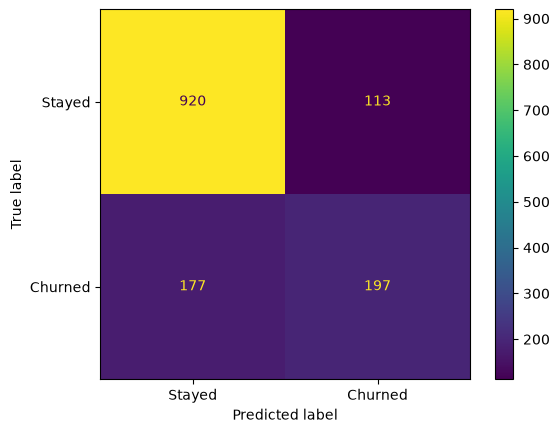

In [211]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.show()

## Confusion Matrix Analysis

The confusion matrix shows how the model performs when classifying customers as churned or retained.

The model correctly identifies many customers who remain, but some customers who eventually churn are missed.

Reducing false negatives is important because these represent customers who are likely to leave but are not identified early enough for retention actions.

In [212]:
feature_importance_sorted = feature_importance.sort_values(
    by="coefficient"
)

feature_importance_sorted.head(10)

,feature,coefficient
1,num__tenure,-1.241924
38,cat__Contract_Two year,-0.851278
15,cat__InternetService_DSL,-0.605167
46,cat__tenure_group_13-24 months,-0.451500
2,num__MonthlyCharges,-0.422910
12,cat__MultipleLines_No,-0.309872
39,cat__PaperlessBilling_No,-0.295172
31,cat__StreamingTV_No internet service,-0.274539
28,cat__TechSupport_No internet service,-0.274539
34,cat__StreamingMovies_No internet service,-0.274539


In [213]:
feature_importance_sorted.tail(10)

,feature,coefficient
14,cat__MultipleLines_Yes,0.108168
27,cat__TechSupport_No,0.132460
18,cat__OnlineSecurity_No,0.157614
43,cat__PaymentMethod_Electronic check,0.172040
35,cat__StreamingMovies_Yes,0.180364
32,cat__StreamingTV_Yes,0.199001
3,num__TotalCharges,0.310879
48,cat__tenure_group_49-72 months,0.415263
16,cat__InternetService_Fiber optic,0.582200
36,cat__Contract_Month-to-month,0.677997


## Feature Importance: Factors Associated With Churn

Logistic Regression coefficients help explain which customer characteristics are associated with higher or lower churn probability.

Positive coefficients indicate factors associated with increased churn risk, while negative coefficients indicate factors associated with customer retention.

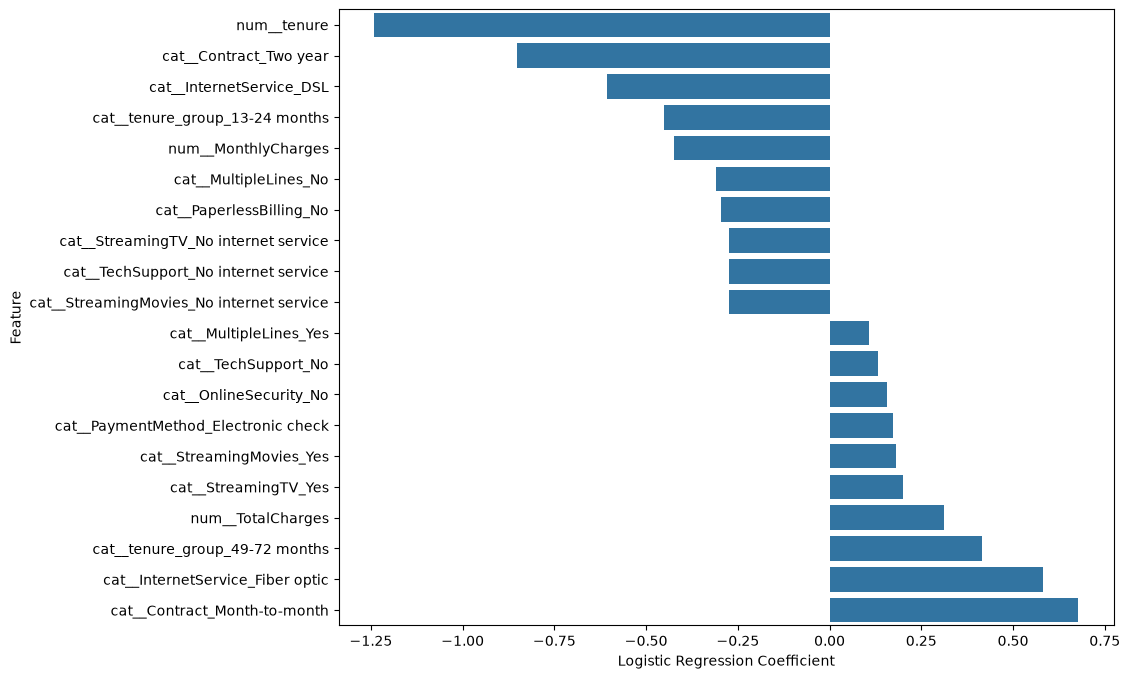

In [214]:
top_features = pd.concat(
    [
        feature_importance_sorted.head(10),
        feature_importance_sorted.tail(10)
    ]
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

## Feature Importance Insights

The model identifies contract type, customer tenure, and internet service as some of the strongest factors associated with churn.

Customers with month-to-month contracts show higher churn risk, while customers with longer tenure and two-year contracts are less likely to churn.

These results are consistent with the exploratory analysis and highlight opportunities for targeted retention strategies.

In [215]:
X_clean = X.drop("tenure_group", axis=1)

In [217]:
X_clean.shape

(7032, 19)

In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [219]:
X_train.shape, X_test.shape

((5625, 19), (1407, 19))

In [220]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [221]:
len(numeric_features), len(categorical_features)

(4, 15)

# 9. Model Improvement

The baseline model included the engineered `tenure_group` feature that was created for exploratory analysis.

Since `tenure` already contains the same information at a finer level of detail, we remove `tenure_group` to reduce feature redundancy and improve model interpretability.

The improved model is trained using the refined feature set and compared against the baseline model.

In [222]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

improved_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [223]:
improved_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [224]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

improved_logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            improved_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

In [225]:
improved_logistic_model.fit(
    X_train,
    y_train
)

print("Improved Logistic Regression model trained successfully.")

Improved Logistic Regression model trained successfully.


In [226]:
improved_y_pred = improved_logistic_model.predict(X_test)

improved_y_pred_proba = improved_logistic_model.predict_proba(X_test)[:, 1]

In [227]:
improved_accuracy = accuracy_score(y_test, improved_y_pred)
improved_precision = precision_score(y_test, improved_y_pred)
improved_recall = recall_score(y_test, improved_y_pred)
improved_f1 = f1_score(y_test, improved_y_pred)
improved_roc_auc = roc_auc_score(y_test, improved_y_pred_proba)

(
    improved_accuracy,
    improved_precision,
    improved_recall,
    improved_f1,
    improved_roc_auc,
)

(0.8038379530916845,
 0.6484848484848484,
 0.5721925133689839,
 0.6079545454545454,
 0.8359290473207676)

## Model Improvement Results

Removing the engineered `tenure_group` feature resulted in a simpler model with slightly better predictive performance.

Since `tenure_group` was derived directly from `tenure`, it introduced redundant information without adding new predictive value.

The refined model achieved improvements across multiple evaluation metrics, suggesting better generalization while remaining easier to interpret.

In [228]:
comparison = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Baseline": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ],
        "Improved": [
            improved_accuracy,
            improved_precision,
            improved_recall,
            improved_f1,
            improved_roc_auc
        ]
    }
)

comparison

,Metric,Baseline,Improved
0,Accuracy,0.793888,0.803838
1,Precision,0.635484,0.648485
2,Recall,0.526738,0.572193
3,F1 Score,0.576023,0.607955
4,ROC-AUC,0.834909,0.835929


## Model Comparison

The refined Logistic Regression model outperformed the baseline model across all evaluation metrics.

Removing the engineered `tenure_group` feature reduced feature redundancy because the original `tenure` variable already captured the same information with greater detail.

The improved model achieved higher accuracy, precision, recall, F1-score, and ROC-AUC while remaining simpler and easier to interpret.

This demonstrates the importance of thoughtful feature selection rather than simply increasing the number of features.